In [16]:
import joblib
import os
import numpy as np

# Loading the trained tree models from directory.

TARGET_DIR = r"C:\Python DAT540\Dat-540-Prosjekt\data\tree_models"

# List of filenames
model_filenames = [
    'dt_baseline_model.joblib',
    'dt_tuned_model_1_CV3.joblib',
    'dt_tuned_model_2_CV5.joblib',
    'dt_tuned_model_3_CV10.joblib',
    'dt_tuned_model_v2_1_CV3_3.joblib',
    'dt_tuned_model_v2_2_CV3_5.joblib',
    'dt_tuned_model_v2_3_CV5_5.joblib'
]

# Initialize a dictionary to store the loaded models
loaded_models = {}

print("Loading models from disk...")

# Iterate, load, and store
for filename in model_filenames:
    # Construct the full path
    full_path = os.path.join(TARGET_DIR, filename)
    
    # Load the model
    model = joblib.load(full_path)
    
    # Create a clean key for the dictionary 
    model_key = filename.replace('.joblib', '')
    
    # Store the loaded model in the dictionary
    loaded_models[model_key] = model
    print(f"Loaded: {model_key}")

print("\nAll models loaded successfully into the 'loaded_models' dictionary.")

# Load processed data
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
feature_names = pd.read_csv("../data/processed/feature_names.csv", header=None)[0].tolist()

Loading models from disk...
Loaded: dt_baseline_model
Loaded: dt_tuned_model_1_CV3
Loaded: dt_tuned_model_2_CV5
Loaded: dt_tuned_model_3_CV10
Loaded: dt_tuned_model_v2_1_CV3_3
Loaded: dt_tuned_model_v2_2_CV3_5
Loaded: dt_tuned_model_v2_3_CV5_5

All models loaded successfully into the 'loaded_models' dictionary.


In [17]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix, log_loss, make_scorer
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the formatted names list and map it to the dictionary keys
# This mapping is crucial for two reasons: 
#   a) Getting the model object from the dictionary (key).
#   b) Getting the nicely formatted name for the plots (value).
model_name_mapping = {
    'dt_baseline_model': 'Baseline\nDecision Tree',
    'dt_tuned_model_1_CV3': 'Tuned Decision\nTree v1 (CV=3)', # Use the loaded key name
    'dt_tuned_model_2_CV5': 'Tuned Decision\nTree v1 (CV=5)', # Use the loaded key name
    'dt_tuned_model_3_CV10': 'Tuned Decision\nTree v1 (CV=10)', # Use the loaded key name
    'dt_tuned_model_v2_1_CV3_3': 'Tuned Decision\nTree v2\n(CV=3, 3 repeats)',
    'dt_tuned_model_v2_2_CV3_5': 'Tuned Decision\nTree v2\n(CV=3, 5 repeats)',
    'dt_tuned_model_v2_3_CV5_5': 'Tuned Decision\nTree v2\n(CV=5, 5 repeats)',
}

# Ensure results_data is reset before running the loop
results_data = []

# Function definition remains the same (as provided in the prompt)
def store_metrics(model, name, X_valid, y_valid):
    y_pred = model.predict(X_valid)
    y_prob = model.predict_proba(X_valid)[:, 1]
    y_proba_all = model.predict_proba(X_valid)
    cm = confusion_matrix(y_valid, y_pred)
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    results_data.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_valid, y_pred),
        'Test AUC': roc_auc_score(y_valid, y_prob),
        'Log Loss': log_loss(y_valid, y_proba_all),
        'Specificity': specificity, 
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP
    })

# 2. Iterate through the mapping and call store_metrics
print("Extracting metrics from loaded models...")

for model_key, display_name in model_name_mapping.items():
    # Access the loaded model object using the key
    model_object = loaded_models[model_key] 
    
    # Run the evaluation
    store_metrics(model_object, display_name, X_valid, y_valid)
    print(f"Metrics stored for: {model_key}")

# 3. Create the final DataFrame
df_results = pd.DataFrame(results_data)

print("\ndf_results created successfully:")

Extracting metrics from loaded models...
Metrics stored for: dt_baseline_model
Metrics stored for: dt_tuned_model_1_CV3
Metrics stored for: dt_tuned_model_2_CV5
Metrics stored for: dt_tuned_model_3_CV10
Metrics stored for: dt_tuned_model_v2_1_CV3_3
Metrics stored for: dt_tuned_model_v2_2_CV3_5
Metrics stored for: dt_tuned_model_v2_3_CV5_5

df_results created successfully:


In [18]:
def plot_model_metrics(df_data, title):
    
    plt.figure(figsize=(14,8)) 
    sns.set_style("whitegrid")

    # Create a bar plot, using 'Metric' for columns and 'Model' for the x-axis
    ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_data)

    # Add labels and title
    plt.title(title, fontsize=16)
    plt.ylabel('Score Value', fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.xticks(ha='center', fontsize=14) 

    # Add the score values on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 7), # Adjusted xytext slightly
                    textcoords='offset points',
                    fontsize=9) # Adjusted font size for more space

    plt.tight_layout()
    plt.show()

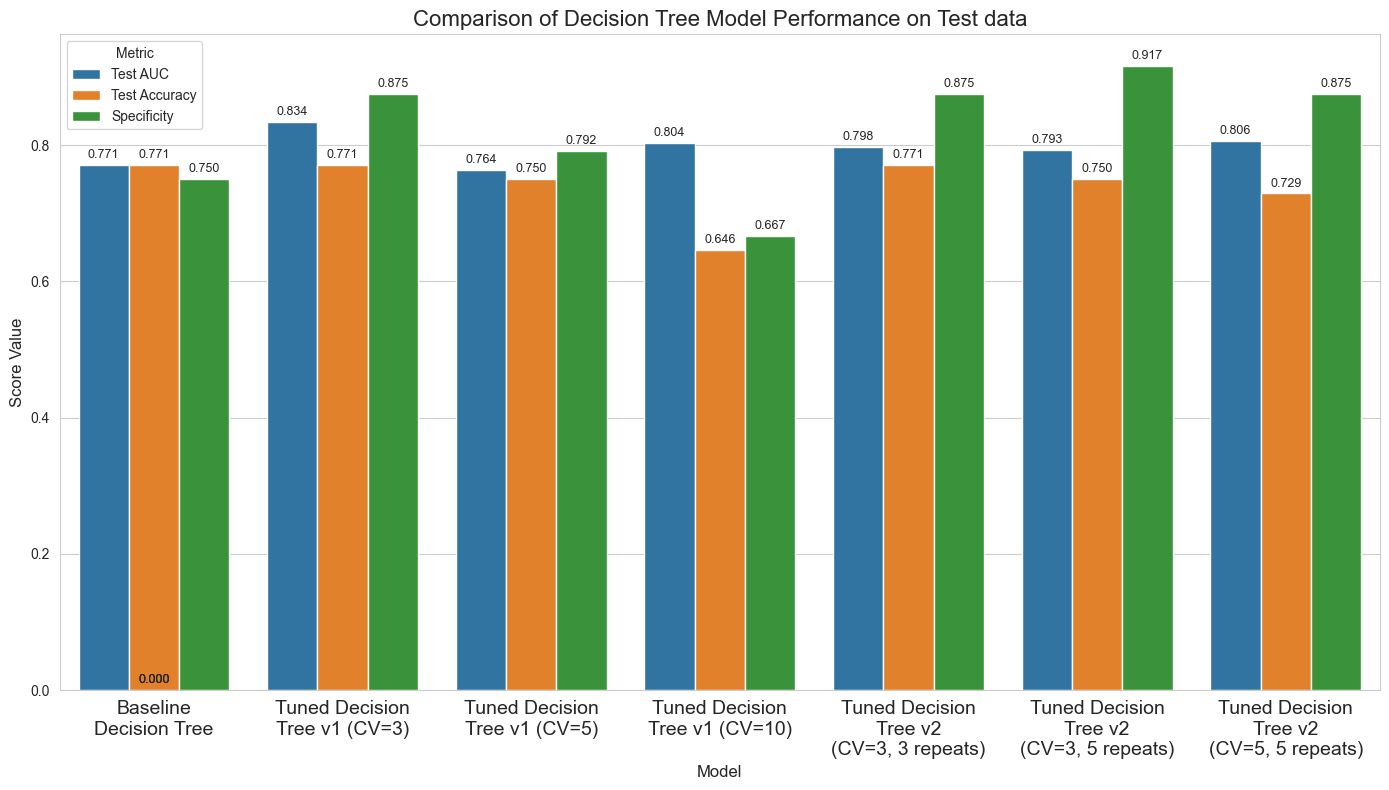

In [19]:
df_plot_primary = df_results.melt(id_vars='Model', 
                                  value_vars=['Test AUC', 'Test Accuracy', 'Specificity'],
                                  var_name='Metric', 
                                  value_name='Score')

plot_model_metrics(df_plot_primary, title='Comparison of Decision Tree Model Performance on Test data')

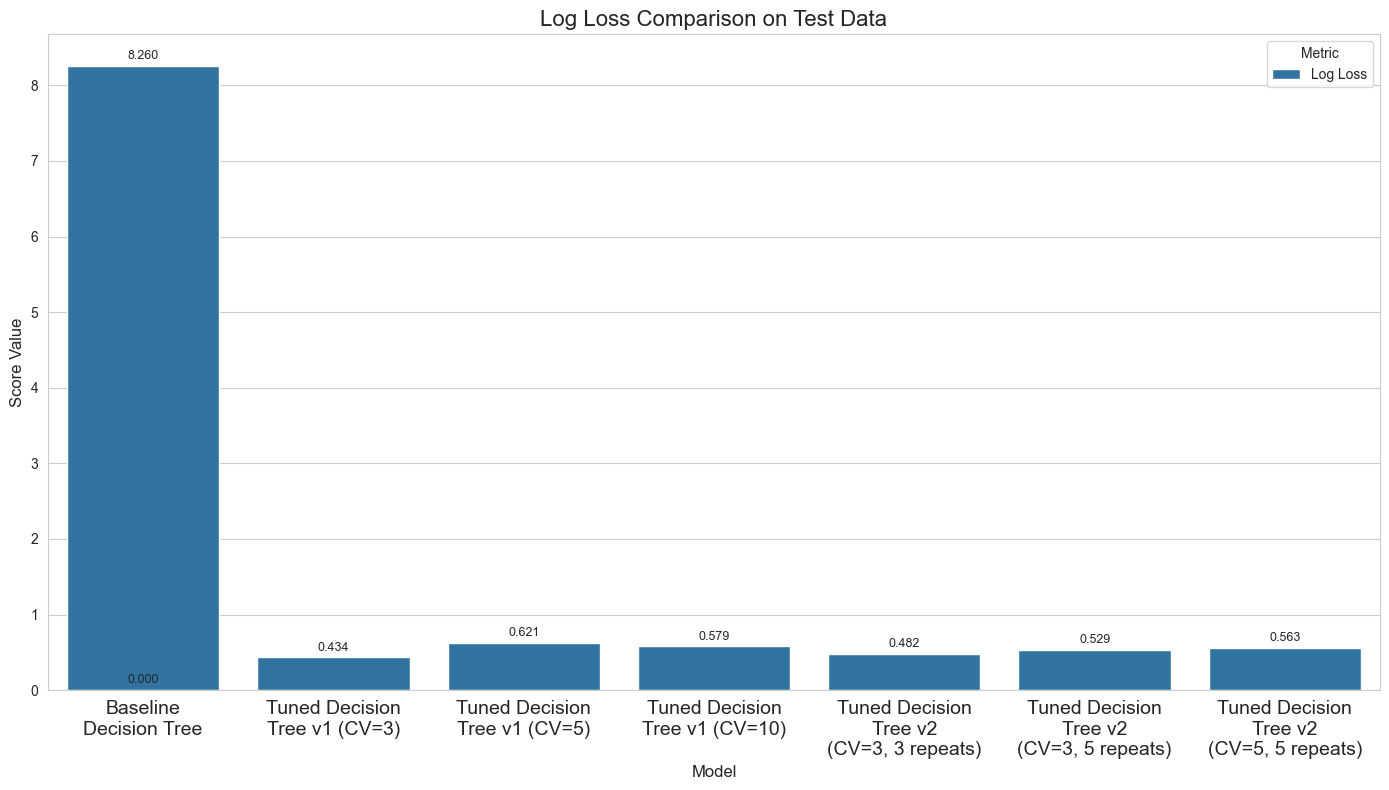

In [20]:
df_plot_logloss = df_results.melt(id_vars='Model', 
                                  value_vars=['Log Loss'],
                                  var_name='Metric', 
                                  value_name='Score')

plot_model_metrics(df_plot_logloss, title='Log Loss Comparison on Test Data') 

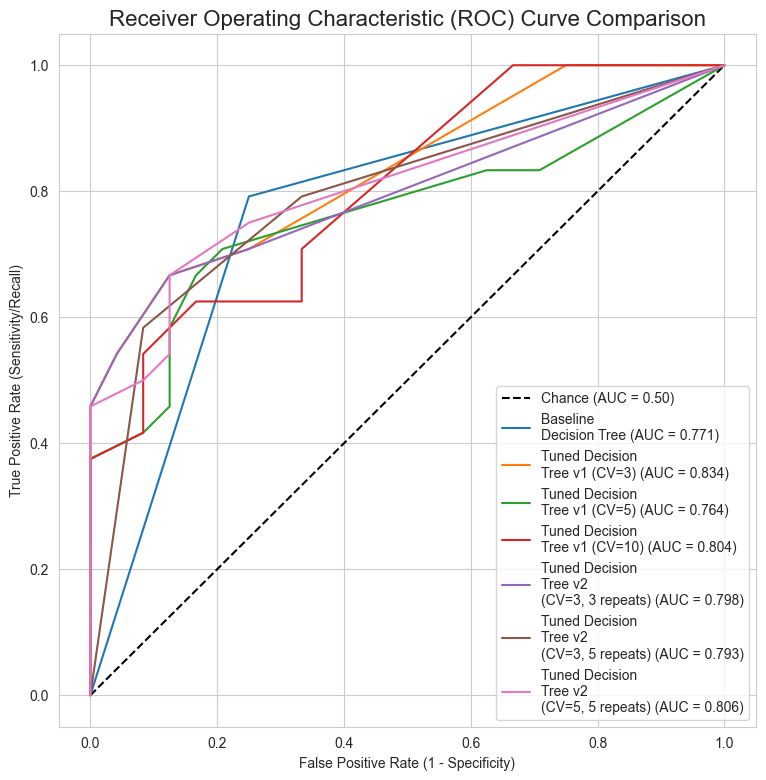

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score 

plt.figure(figsize=(9, 9))
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)') # Baseline line

# --- 1. Get ordered lists from the mapping ---
# Keys are the simple names used in the loaded_models dictionary
model_keys = list(model_name_mapping.keys())

# Values are the formatted names with line breaks
model_display_names = list(model_name_mapping.values())

# --- 2. Iterate using the mapping ---
# We loop through the keys and names simultaneously
for key, name in zip(model_keys, model_display_names):
    
    # Retrieve the fitted model object from the dictionary
    model = loaded_models[key]
    
    # Get probabilities for the positive class
    y_prob = model.predict_proba(X_valid)[:, 1]
    
    # Calculate ROC curve metrics
    fpr, tpr, _ = roc_curve(y_valid, y_prob)
    
    # Get AUC score from the pre-calculated df_results (as you did previously)
    # This ensures consistency with your bar charts
    roc_auc = df_results[df_results['Model'] == name]['Test AUC'].iloc[0]
    
    # Plot the curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# Final plot configuration
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()